# Wine Quality Analysis

Dataset link : https://archive.ics.uci.edu/dataset/186/wine+quality

Kaggle Dataset link : https://www.kaggle.com/datasets/yasserh/wine-quality-dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load dataset
df = pd.read_csv("data/WineQT.csv")

In [3]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [7]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


C:\Users\abhis\AppData\Local\Temp\ipykernel_27796\1957365507.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="quality", data=df, palette="viridis")


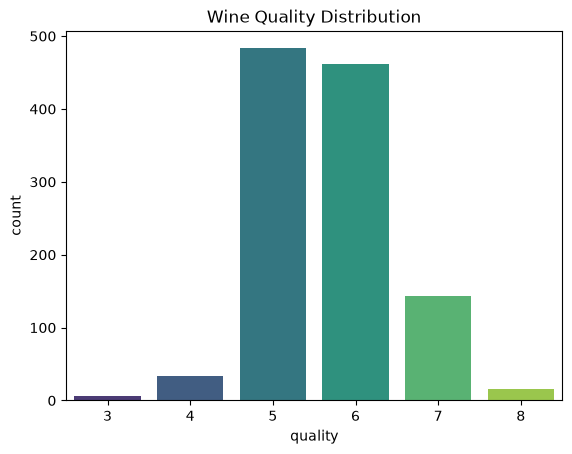

In [8]:
# Distribution of Target Variable (Quality)

sns.countplot(x="quality", data=df, palette="viridis")
plt.title("Wine Quality Distribution")
plt.show()

In [9]:
# Summary
print(df['quality'].value_counts().sort_index())

quality
3      6
4     33
5    483
6    462
7    143
8     16
Name: count, dtype: int64


In [10]:
# Feature Distributions

df.drop("Id", axis=1, inplace=True)

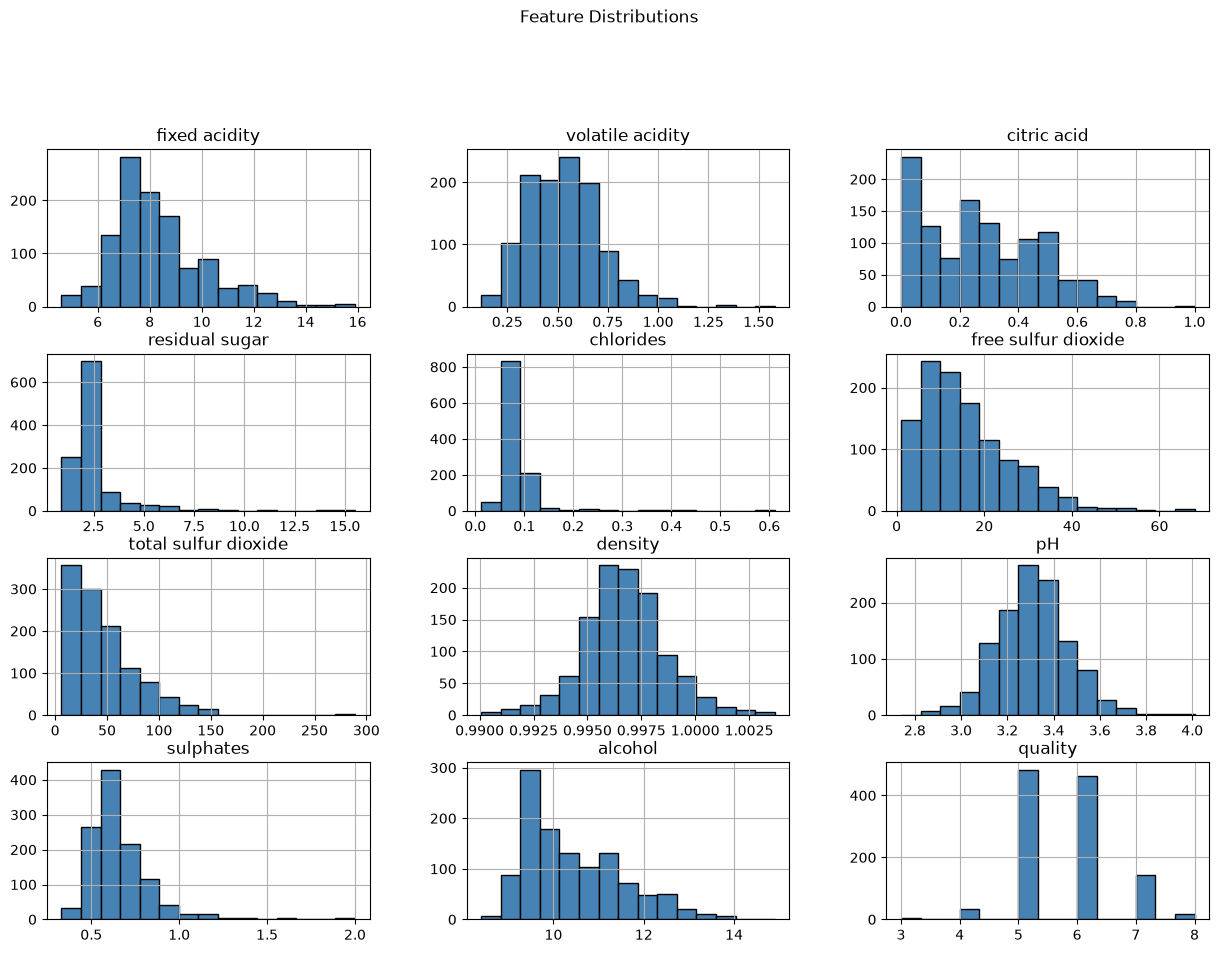

In [11]:
df.hist(bins=15, figsize=(15,10), color="steelblue", edgecolor="black")
plt.suptitle("Feature Distributions", y=1.02)
plt.show()

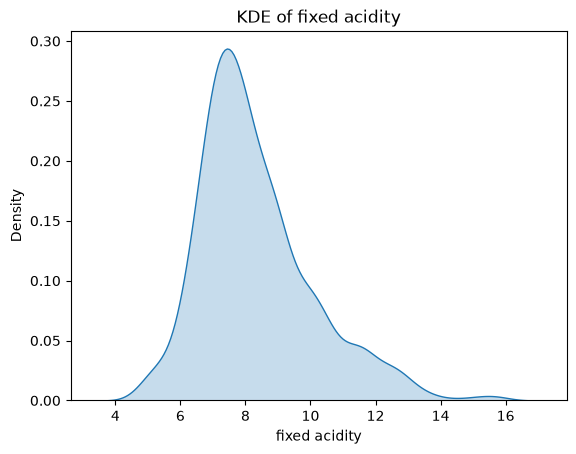

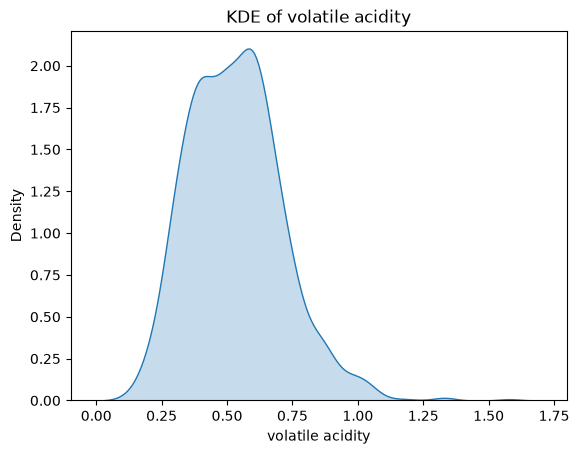

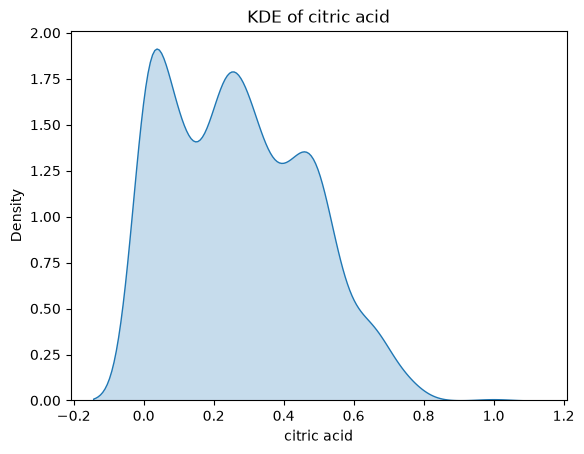

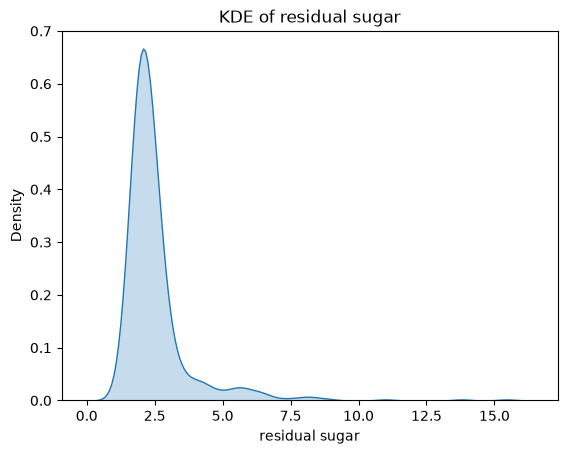

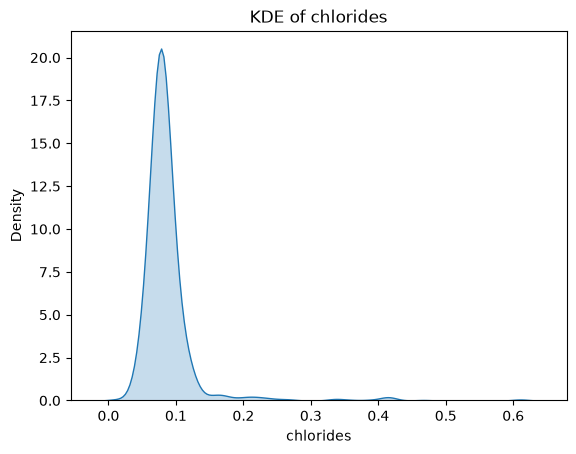

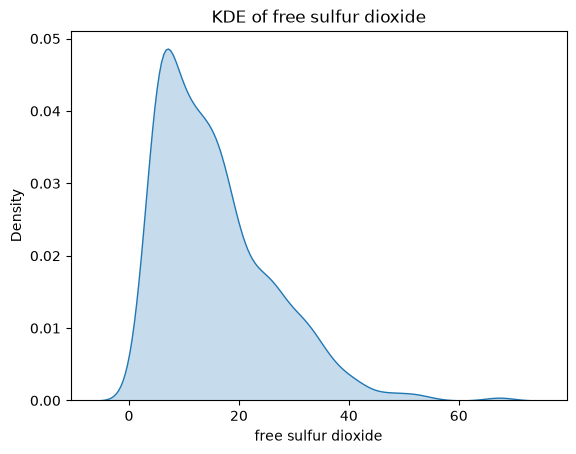

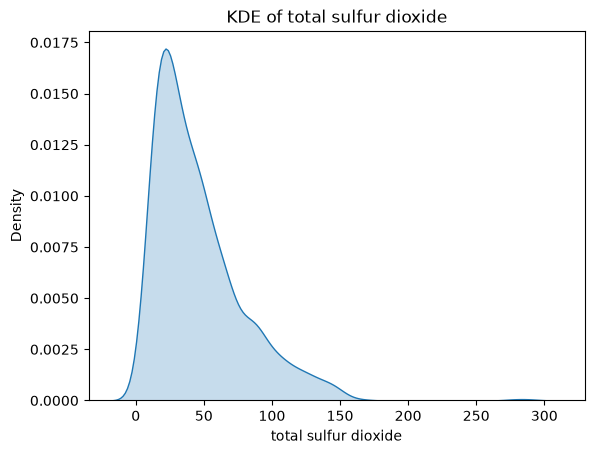

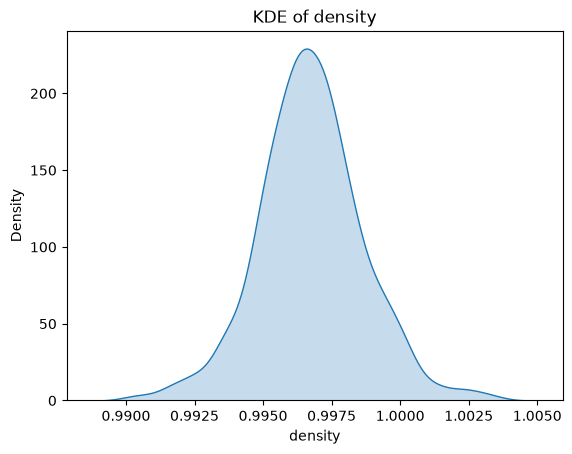

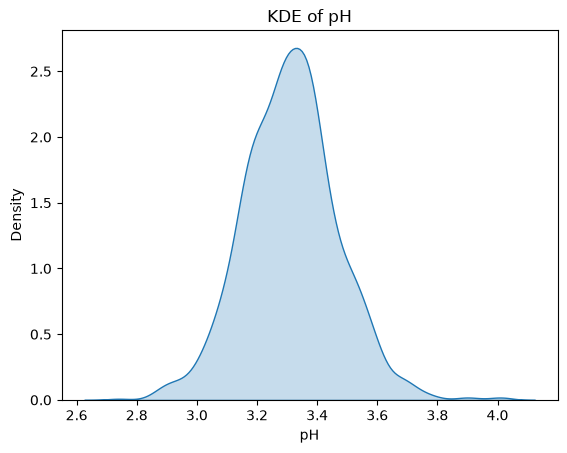

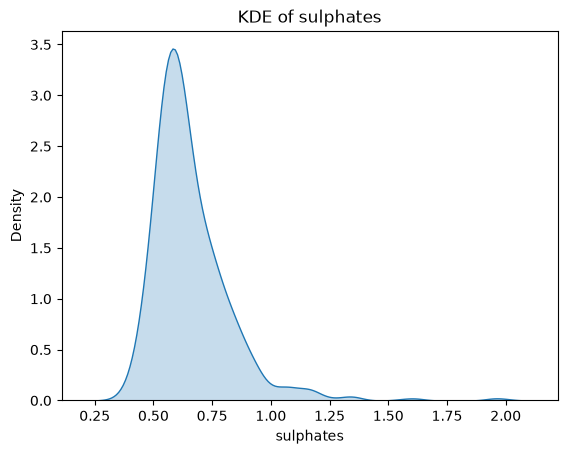

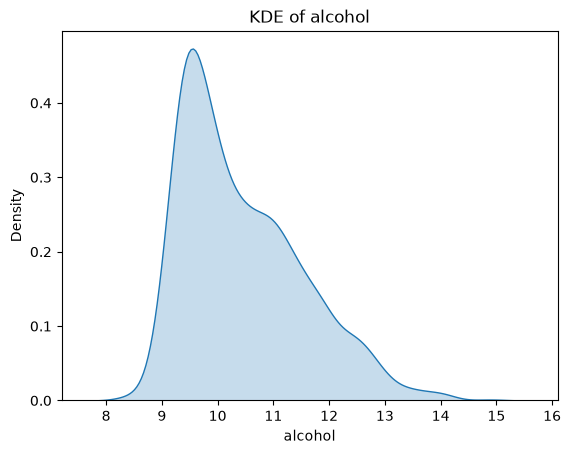

In [12]:
# KDE plots for smooth density
for col in df.drop(columns=["quality"]).columns:
    sns.kdeplot(df[col], fill=True)
    plt.title(f"KDE of {col}")
    plt.show()

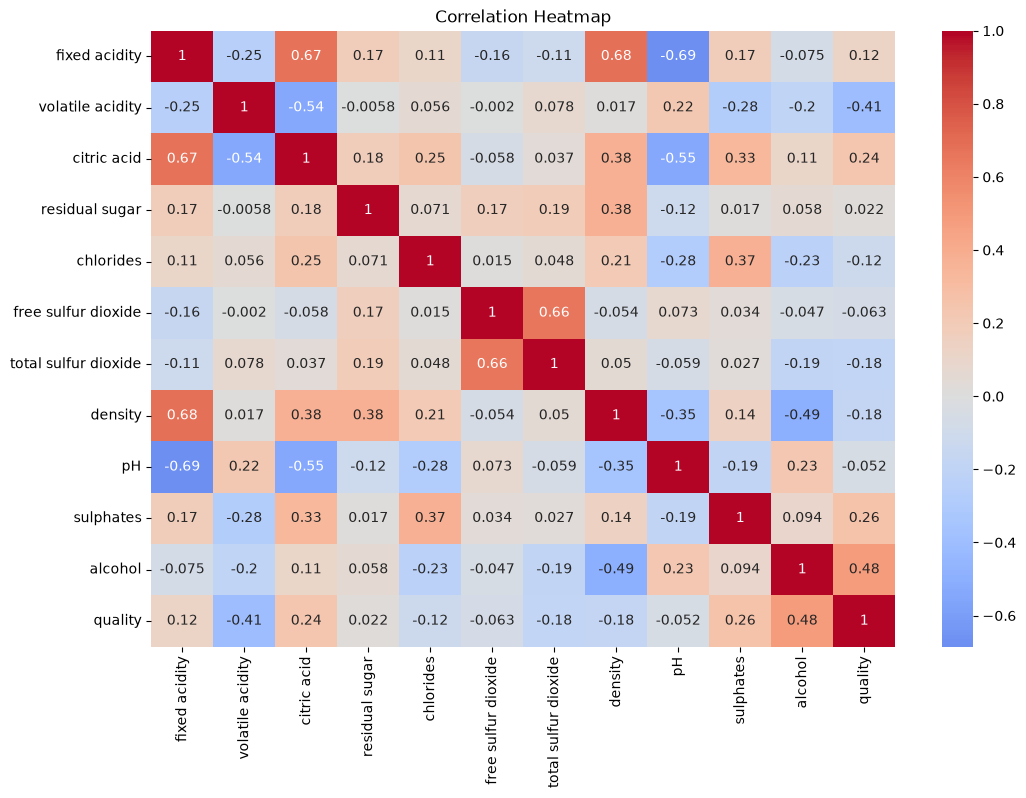

In [13]:
# Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

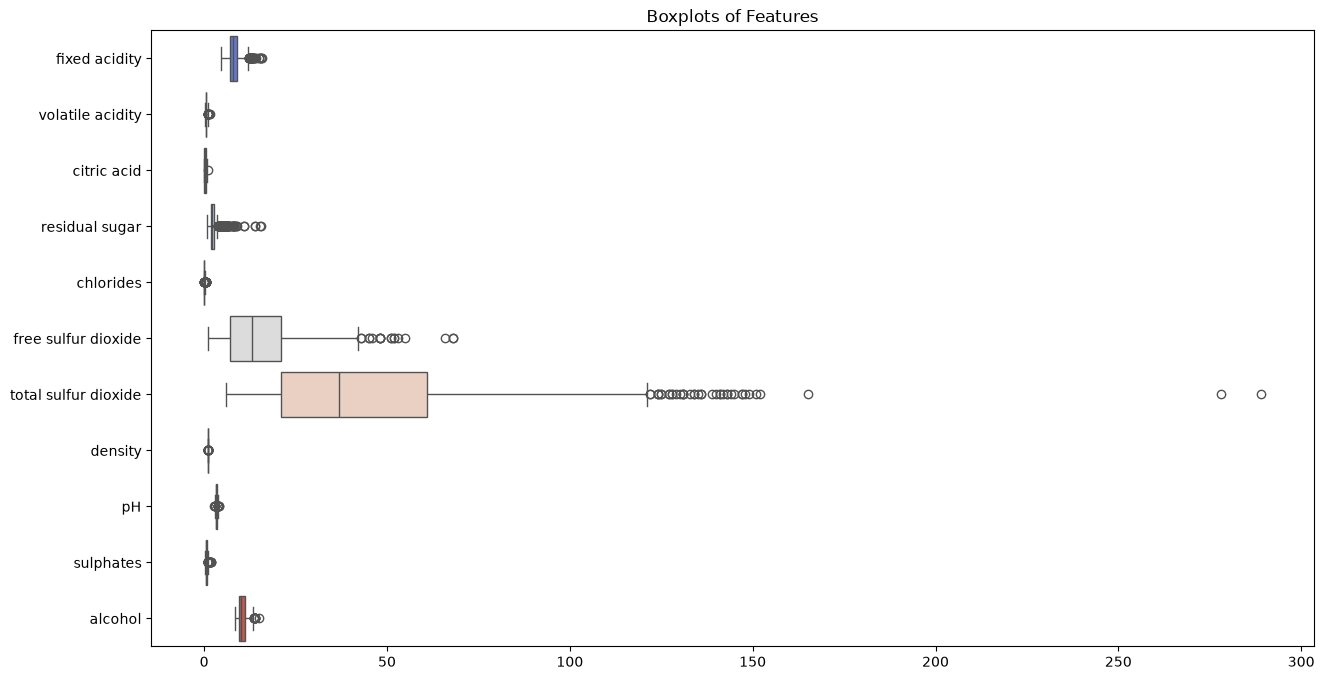

In [14]:
# Boxplots to check outliers
plt.figure(figsize=(15,8))
sns.boxplot(data=df.drop(columns=["quality"]), orient="h", palette="coolwarm")
plt.title("Boxplots of Features")
plt.show()

In [15]:
df.columns.to_list()

['fixed acidity',
 'volatile acidity',
 'citric acid',
 'residual sugar',
 'chlorides',
 'free sulfur dioxide',
 'total sulfur dioxide',
 'density',
 'pH',
 'sulphates',
 'alcohol',
 'quality']

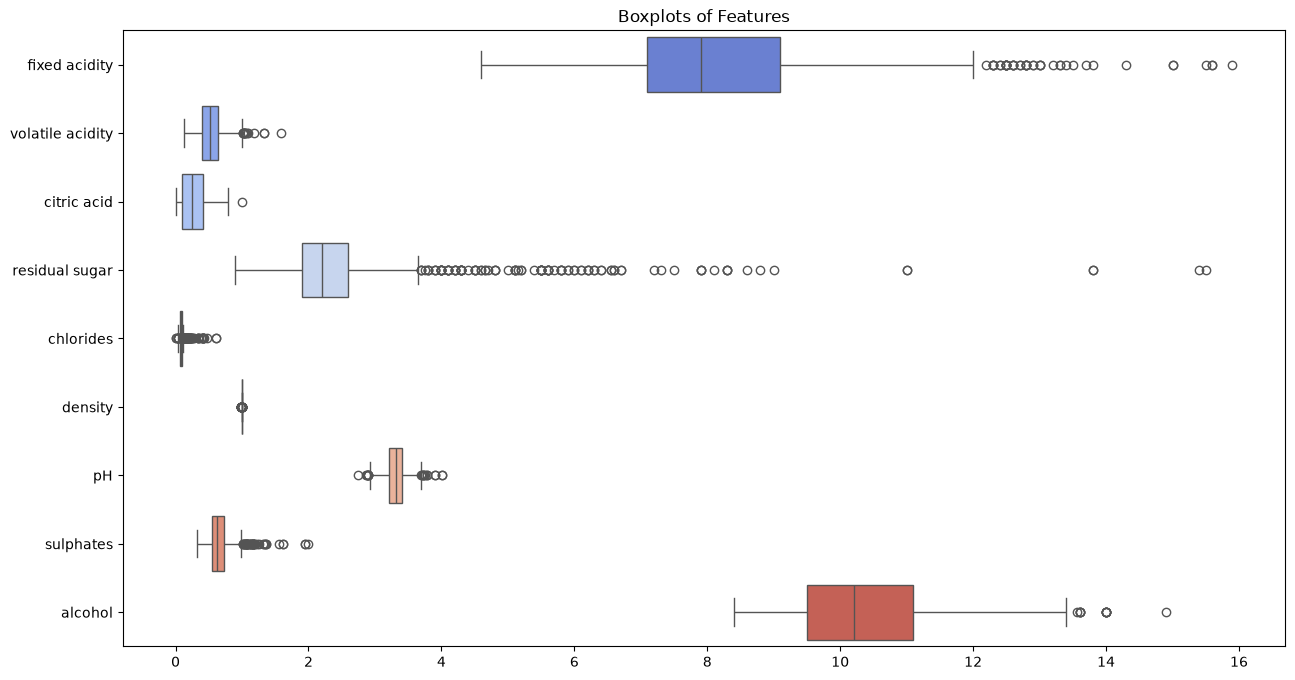

In [16]:
# Boxplots to check outliers
plt.figure(figsize=(15,8))
sns.boxplot(data=df.drop(columns=["quality", "free sulfur dioxide", "total sulfur dioxide"]), orient="h", palette="coolwarm")
plt.title("Boxplots of Features")
plt.show()

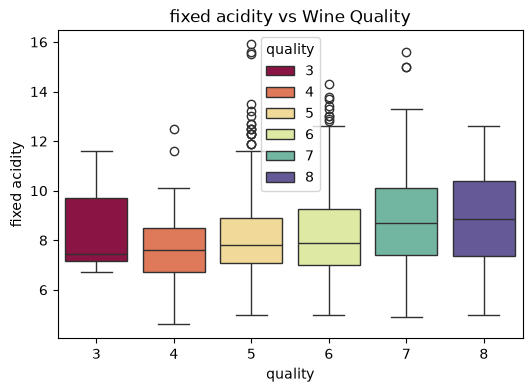

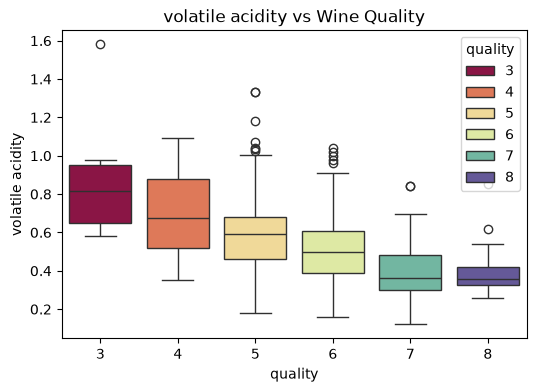

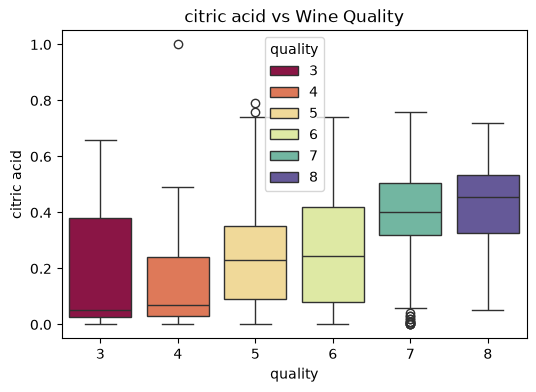

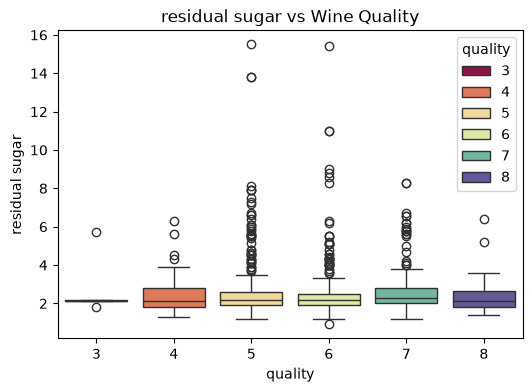

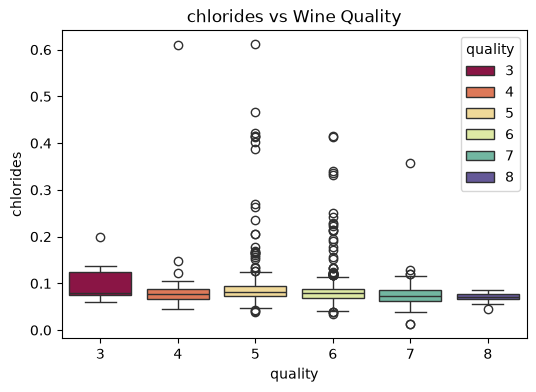

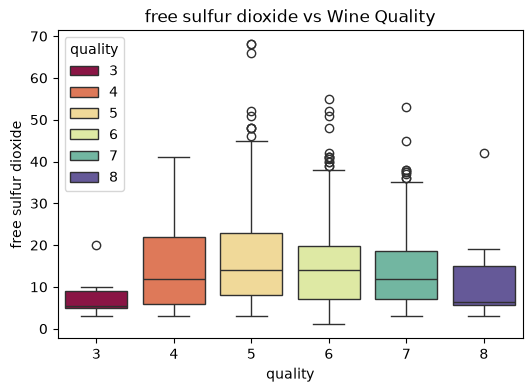

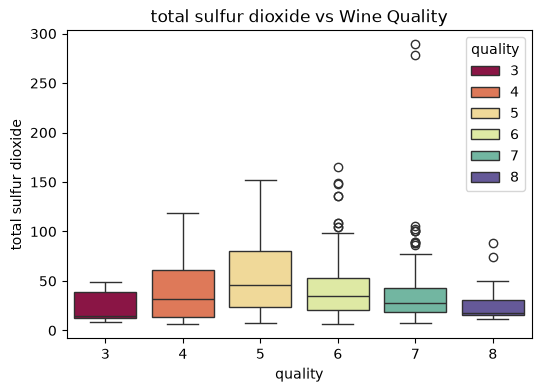

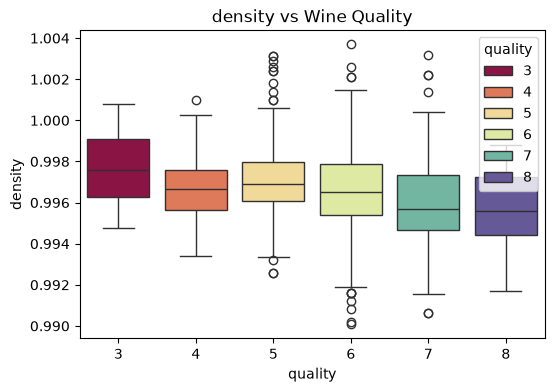

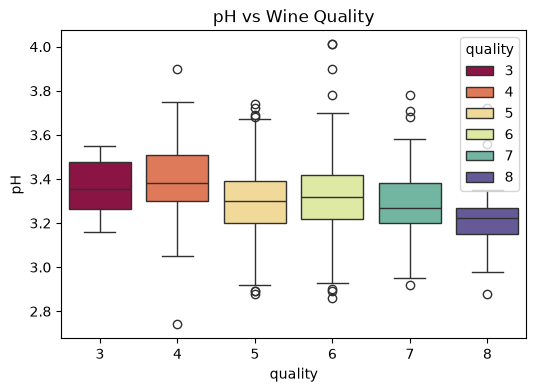

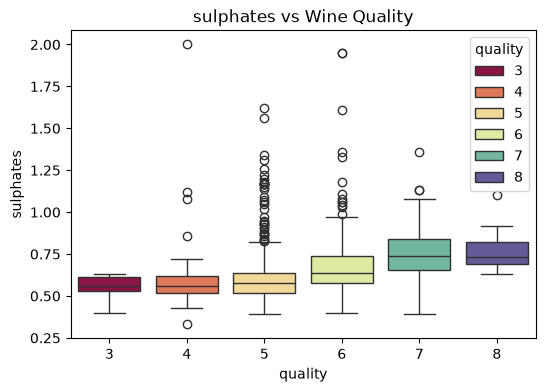

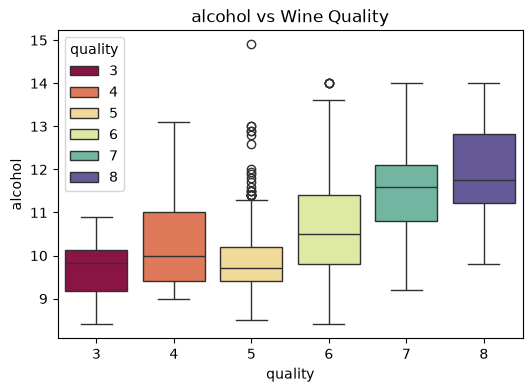

In [17]:
# Feature vs Target (Quality)
for col in df.drop(columns=["quality"]).columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x="quality", y=col, data=df, palette="Spectral", hue="quality")
    plt.title(f"{col} vs Wine Quality")
    plt.show()

In [18]:
# Outlier Detection (IQR method)
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1
outliers = ((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).sum()
print("Outliers per feature:", outliers)

Outliers per feature: fixed acidity            44
volatile acidity         14
citric acid               1
residual sugar          110
chlorides                77
free sulfur dioxide      18
total sulfur dioxide     40
density                  36
pH                       20
sulphates                43
alcohol                  12
quality                  22
dtype: int64


In [19]:
# Optional cleaned dataset
df_cleaned = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]
print("Original shape:", df.shape)
print("Cleaned shape:", df_cleaned.shape)

Original shape: (1143, 12)
Cleaned shape: (834, 12)


A **pair plot** (also known as a **scatter plot matrix**) is a grid of plots that visualizes the pairwise relationships between every numerical variable in your dataset, all in a single view.

If you have 4 numerical features, a pair plot creates a $4 \times 4$ grid showing how each variable interacts with every other variable.

## How to Read and Interpret a Pair Plot

To read a pair plot, treat it like a distance matrix or a multiplication table where you look at the intersection of a **row variable** and a **column variable**.

### 1. The Off-Diagonal Plots (Scatter Plots)

Every box that is **not** on the main diagonal is a **scatter plot** between two distinct variables:

- **Linear Trends:** Look for points forming a straight diagonal line. For example, in the image above, intersecting `flipper_length_mm` (row) with `body_mass_g` (column) shows a clear upward trend—as flipper length increases, body mass increases.
- **Clusters & Groups:** If points form distinct separate clusters (especially when color-coded by a categorical label, like penguin species), it tells you those two variables are great for separating categories.
- **Outliers:** Points lying far outside the main group stand out instantly in these plots.

### 2. The Diagonal Plots (Histograms / KDE Curves)

Where a variable intersects with **itself** (e.g., `bill_length_mm` vs `bill_length_mm`), a scatter plot would just be a useless straight line.

Instead, the diagonal shows the **univariate distribution** (how a single variable is spread out) using a **histogram** or a smoothed curve called a **KDE (Kernel Density Estimation)** plot:

- **Symmetry vs. Skew:** Shows if a single variable follows a normal bell curve or is skewed to one side.
- **Multimodal Peaks:** If a curve has two peaks (bimodal), it suggests your data naturally splits into two distinct subgroups.

## Why Pair Plots Are Extremely Useful

| Use Case | How Pair Plots Help |
| --- | --- |
| **Exploratory Data Analysis (EDA)** | Gives you an instant "birds-eye view" of all continuous relationships without plotting dozens of individual graphs manually. |
| **Spotting Multicollinearity** | Highlights feature pairs with strong correlations ($r \approx 1$ or $-1$), which can break linear regression models. |
| **Feature Selection** | Shows which variables cleanly separate target classes (e.g., noticing green dots separate completely from blue/orange dots). |
| **Checking Model Assumptions** | Helps verify if features are normally distributed (diagonal) or linearly related (off-diagonal) before applying statistical models. |

## A Important Limitation

Pair plots are fantastic, but they don't scale well with **large feature counts**.

If you have 20 numerical columns, a pair plot generates a $20 \times 20$ grid—meaning **400 individual plots**, which will render tiny, unreadable, and freeze your computer. For high-dimensional datasets, a **Correlation Heatmap** is usually better.

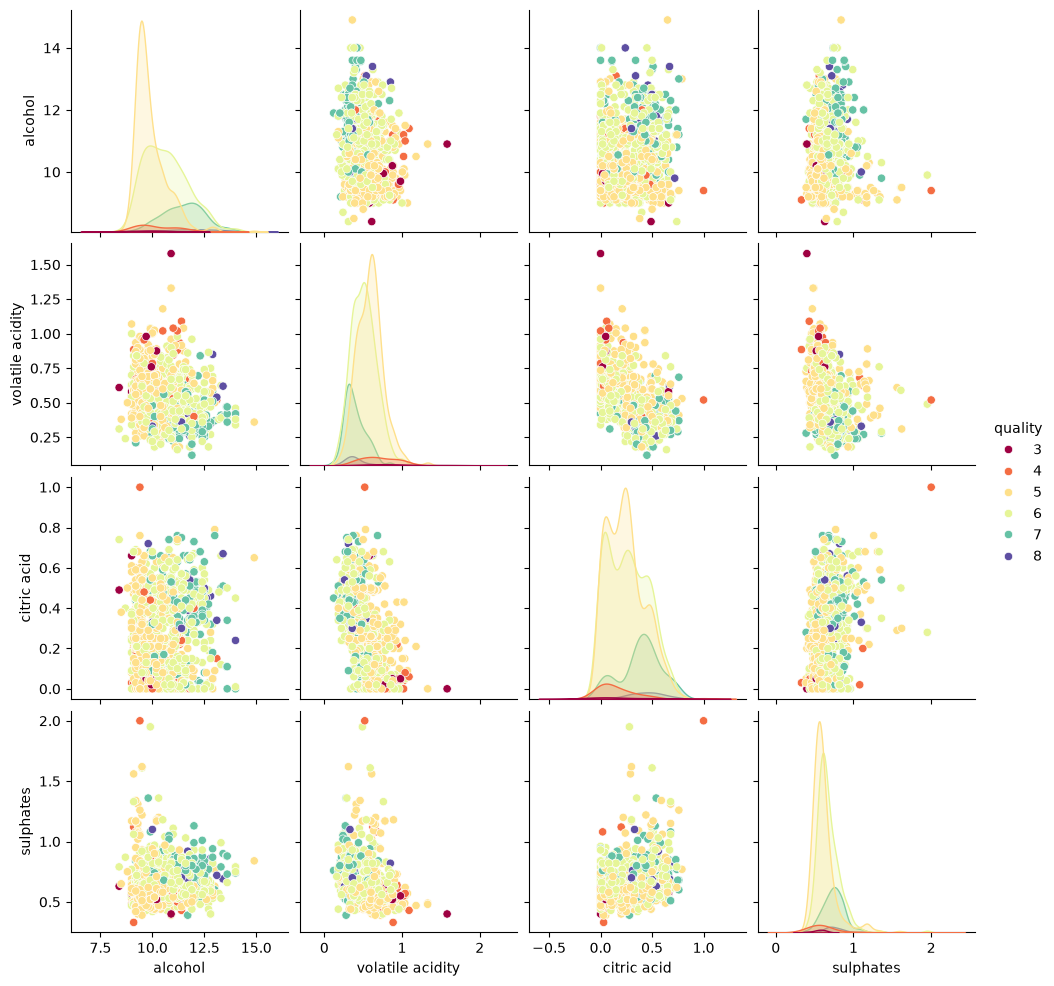

In [ ]:
# Pairplot for selected features (interesting relationships)
# Pairplot is a great way to visualize pairwise relationships in a dataset. It creates a grid of Axes
# such that each variable in the data will be shared across the y-axes across a single row and the x-axes across a single column. This allows for easy comparison of multiple variables at once.
sns.pairplot(df[["alcohol", "volatile acidity", "citric acid", "sulphates", "quality"]],
             hue="quality", palette="Spectral", diag_kind="kde")

# Summary of EDA

- Quality distribution: Most wines are rated 5–7, very few extreme low/high.

Key correlations:

- Alcohol ↑  : Quality ↑ (higher alcohol → better wine). 3,4 Group-1, 5,6,7,8 Group-2

- Volatile acidity ↑ : Quality ↓ (more acidic → worse wine).

- Citric acid, sulphates, density also show patterns.

- Outliers: Present in residual sugar, sulphates, alcohol.

Insight: Higher-quality wines tend to have higher alcohol, lower volatile acidity, higher citric acid & sulphates.

# inferential analysis

In [ ]:
import numpy as np
from scipy.stats import ttest_ind

In [ ]:
# Define low-quality (≤5) and high-quality (≥7) wines
low_quality = df[df["quality"] <= 5]
high_quality = df[df["quality"] >= 7]

In [ ]:
print("Low-quality wines:", len(low_quality))
print("High-quality wines:", len(high_quality))

In [ ]:
t_results = {}
for col in df.drop(columns=["quality"]).columns:
    t_stat, p_val = ttest_ind(low_quality[col], high_quality[col], equal_var=False)
    t_results[col] = {"t-stat": t_stat, "p-value-full": f"{p_val}", "p-value": f"{p_val:.6f}"}


In [ ]:
t_results_df = pd.DataFrame(t_results).T.sort_values("p-value")

In [ ]:
t_results_df

In [ ]:
# Assignment : Perform the same with sample, Count : [100 - 150 (random)], random_state = random